In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split


In [ ]:
import pandas as pd

# Load the Excel file
df = pd.read_excel('/content/Initial Public Offering (Updated).xlsx')

display(df.head())
display(df.tail())
display(df.info())
display(df.describe())

,Date,IPO_Name,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,List Price,Listing Gain,CMP(BSE),CMP(NSE),Current Gains
0,2026-05-14,Bagmane Prime Offi...,3405.00,17.09,15.79,0.00,16.50,100,103.4,3.40,103.92,103.97,3.92
1,2026-05-08,Onemi Technology S...,925.92,24.87,6.57,2.03,9.50,171,191.0,11.70,231.70,231.74,35.50
2,2026-04-29,Citius Transnet In...,1105.00,8.54,11.77,0.00,10.01,100,104.5,4.50,105.87,106.04,5.87
3,2026-04-17,Om Power Transmiss...,150.06,3.65,7.06,1.54,3.33,175,181.1,3.49,190.80,190.74,9.03
4,2026-04-02,Sai Parenteral's L...,408.79,1.71,2.36,0.12,1.05,392,405.0,3.32,487.10,486.70,24.26


,Date,IPO_Name,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,List Price,Listing Gain,CMP(BSE),CMP(NSE),Current Gains
647,2010-02-03,Infinite Computer Solutions Limited,189.80,48.44,106.02,11.08,43.22,165,178.35,8.09,473.75,473.75,187.12
648,2010-01-06,D B Corp Limited,384.22,68.52,26.17,3.42,39.54,212,250.00,17.92,274.75,273.00,29.60
649,2010-01-05,Godrej Properties Limited,468.85,7.45,0.41,0.38,4.00,490,510.00,4.08,1956.80,1952.10,299.35
650,2010-01-04,JSW Energy Limited,2700.00,2.88,0.15,0.40,1.68,100,102.00,2.00,536.30,536.40,436.30
651,2010-01-11,MBL Infrastructure Limited,102.60,3.35,2.65,0.40,1.97,180,190.00,5.56,40.75,40.78,-77.36


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                652 non-null    datetime64[ns]
 1   IPO_Name            652 non-null    object        
 2   Issue_Size(crores)  652 non-null    float64       
 3   QIB                 650 non-null    float64       
 4   HNI                 650 non-null    float64       
 5   RII                 650 non-null    float64       
 6   Total               650 non-null    float64       
 7   Offer Price         652 non-null    int64         
 8   List Price          652 non-null    float64       
 9   Listing Gain        650 non-null    float64       
 10  CMP(BSE)            650 non-null    float64       
 11  CMP(NSE)            642 non-null    float64       
 12  Current Gains       649 non-null    float64       
dtypes: datetime64[ns](1), float64(10), int64(1), objec

None

,Date,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,List Price,Listing Gain,CMP(BSE),CMP(NSE),Current Gains
count,652,652.000000,650.000000,650.000000,650.000000,650.000000,652.000000,652.000000,650.000000,650.000000,642.000000,649.000000
mean,2020-02-06 22:40:29.447852800,1444.556396,48.771169,71.257385,15.913738,37.167046,358.694785,419.785690,16.480338,633.441831,644.354019,73.202761
min,2010-01-04 00:00:00,23.000000,0.000000,0.000000,0.000000,0.110000,10.000000,0.000000,-38.890000,0.040000,0.050000,-99.930000
25%,2016-05-09 18:00:00,269.477500,2.630000,1.840000,1.402500,2.260000,121.750000,135.075000,-0.065000,119.925000,121.172500,-33.200000
50%,2021-11-18 00:00:00,599.785000,13.595000,13.350000,4.780000,10.765000,252.000000,286.625000,5.800000,285.750000,288.250000,12.310000
75%,2024-09-24 00:00:00,1272.290000,77.295000,76.345000,14.610000,56.617500,481.250000,548.500000,23.060000,671.050000,706.012500,91.380000
max,2026-05-14 00:00:00,27858.800000,420.570000,958.070000,374.810000,326.490000,2165.000000,2725.000000,252.760000,15924.100000,15892.000000,2523.670000
std,NaN,2628.744869,66.549173,130.586078,32.483974,52.977874,326.819563,415.339727,30.721293,1141.908775,1148.343680,243.124515


In [ ]:
df.isnull().sum()

,0
Date,0
IPO_Name,0
Issue_Size(crores),0
QIB,2
HNI,2
RII,2
Total,2
Offer Price,0
List Price,0
Listing Gain,2


In [ ]:
#removing nulls from data

# Drop rows where critical subscription/listing data is missing
df_cleaned = df.dropna(subset=['Total', 'Listing Gain', 'CMP(BSE)'])

# Fill missing NSE prices with the corresponding BSE price
df_cleaned['CMP(NSE)'] = df_cleaned['CMP(NSE)'].fillna(df_cleaned['CMP(BSE)'])

df_cleaned = df_cleaned.dropna(subset=['Current Gains'])
df_cleaned.isnull().sum()



/tmp/ipykernel_7387/1292573834.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['CMP(NSE)'] = df_cleaned['CMP(NSE)'].fillna(df_cleaned['CMP(BSE)'])


,0
Date,0
IPO_Name,0
Issue_Size(crores),0
QIB,0
HNI,0
RII,0
Total,0
Offer Price,0
List Price,0
Listing Gain,0


In [ ]:
df_cleaned['Listing_gains_profit']=np.where(df_cleaned['Listing Gain']>0,1,0)
df_cleaned['Listing_gains_profit'].describe()

,Listing_gains_profit
count,645.000000
mean,0.683721
std,0.465384
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
df_cleaned=df_cleaned.drop(['Date','IPO_Name','Listing Gain','List Price','CMP(BSE)','CMP(NSE)','Current Gains'], axis=1, errors='ignore')
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 645 entries, 0 to 651
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Issue_Size(crores)    645 non-null    float64
 1   QIB                   645 non-null    float64
 2   HNI                   645 non-null    float64
 3   RII                   645 non-null    float64
 4   Total                 645 non-null    float64
 5   Offer Price           645 non-null    int64  
 6   Listing_gains_profit  645 non-null    int64  
dtypes: float64(5), int64(2)
memory usage: 40.3 KB


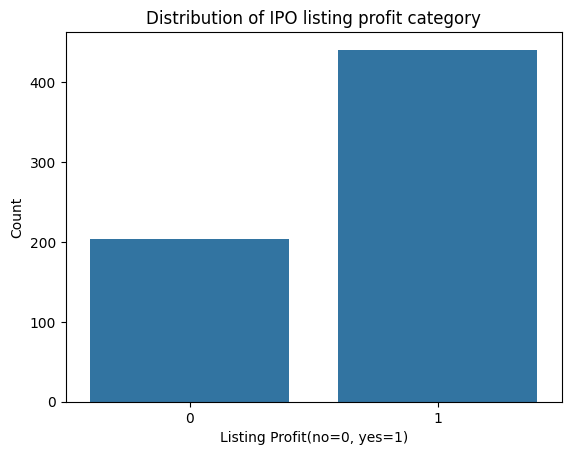

In [ ]:
#visualising target variable
sns.countplot(x='Listing_gains_profit', data=df_cleaned)
plt.title('Distribution of IPO listing profit category')
plt.xlabel('Listing Profit(no=0, yes=1)')
plt.ylabel('Count')
plt.show()

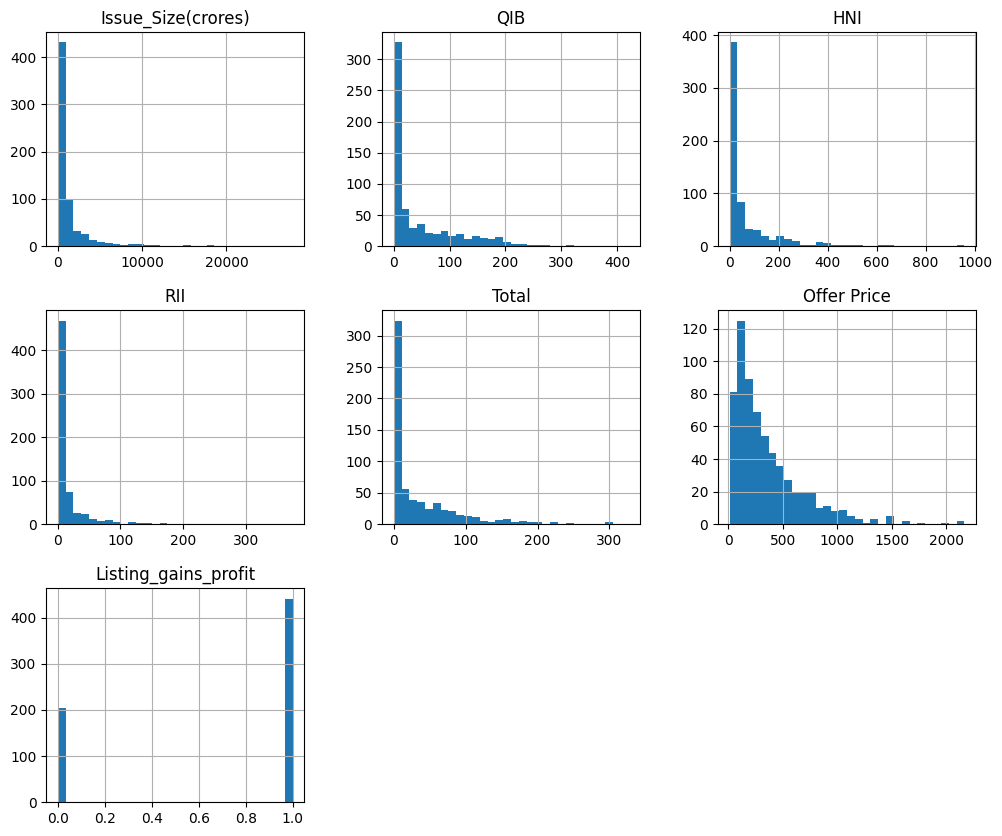

In [ ]:
df_cleaned.hist(bins=30, figsize=(12,10))
plt.show()

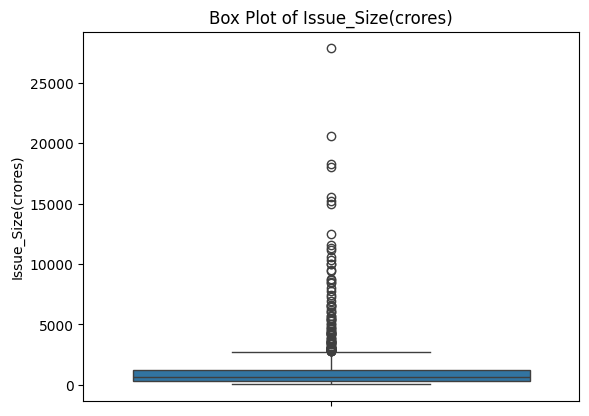

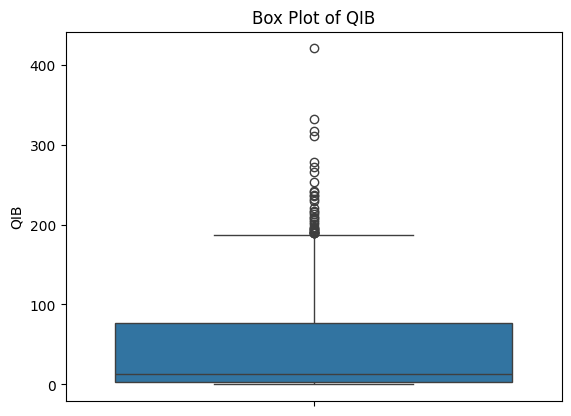

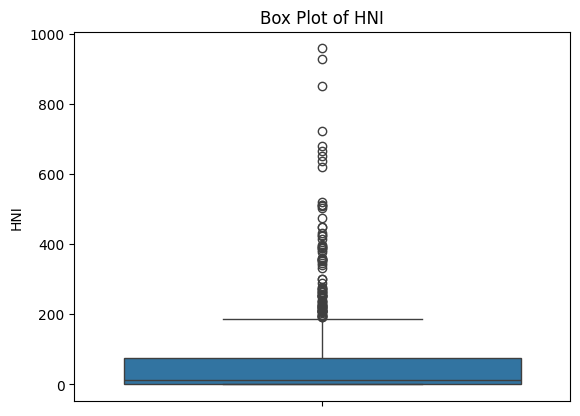

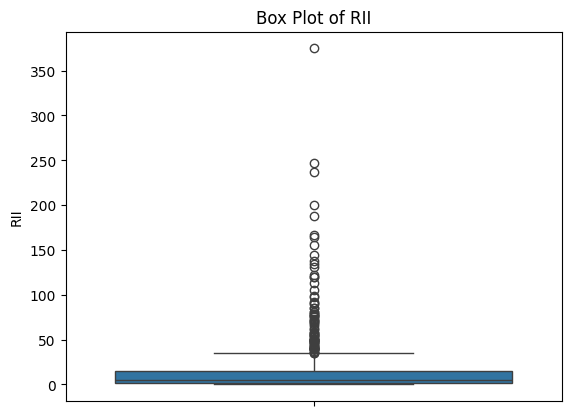

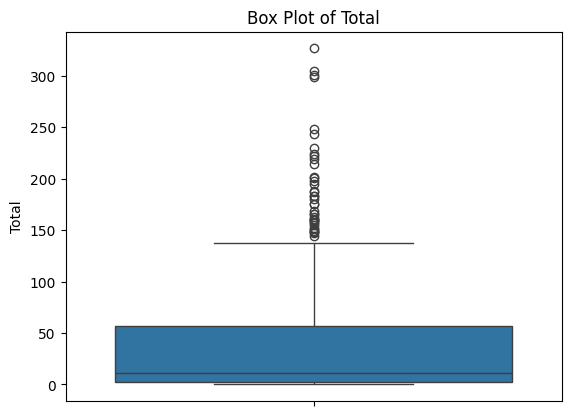

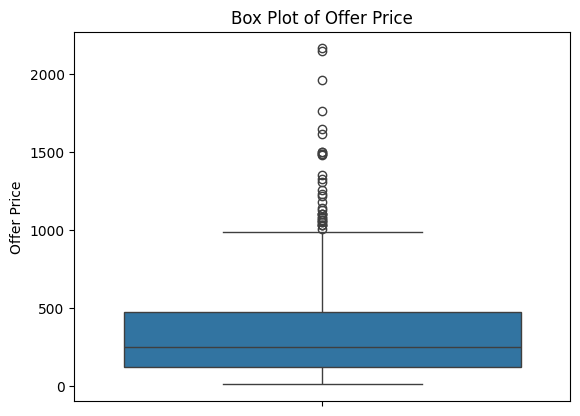

In [ ]:
for col in ['Issue_Size(crores)', 'QIB','HNI','RII','Total','Offer Price']:
  sns.boxplot(data=df_cleaned, y=col)
  plt.title(f'Box Plot of {col}')
  plt.show()


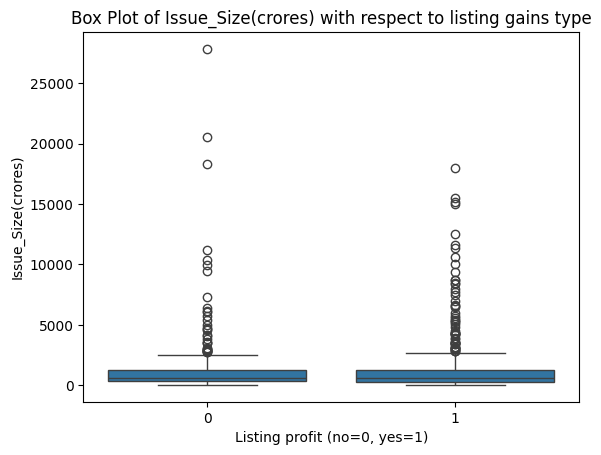

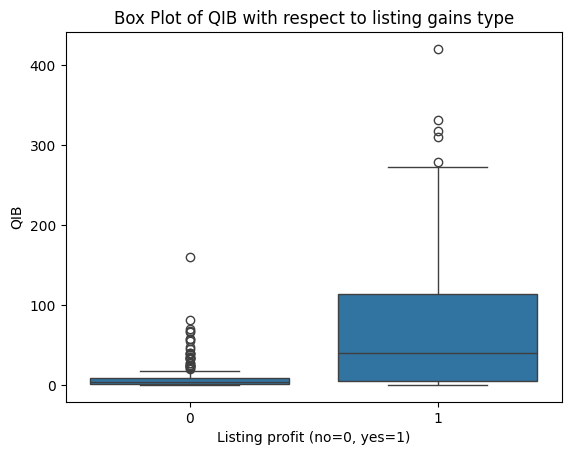

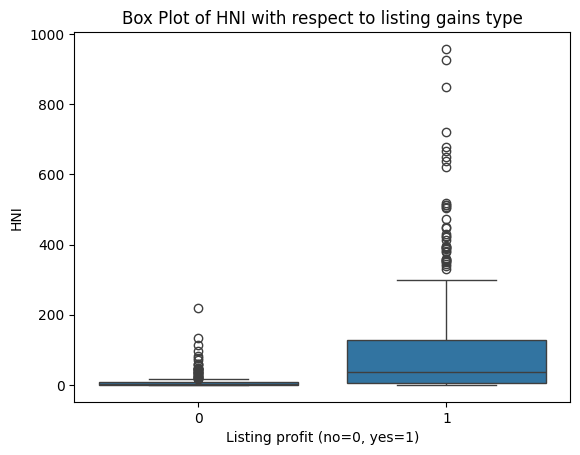

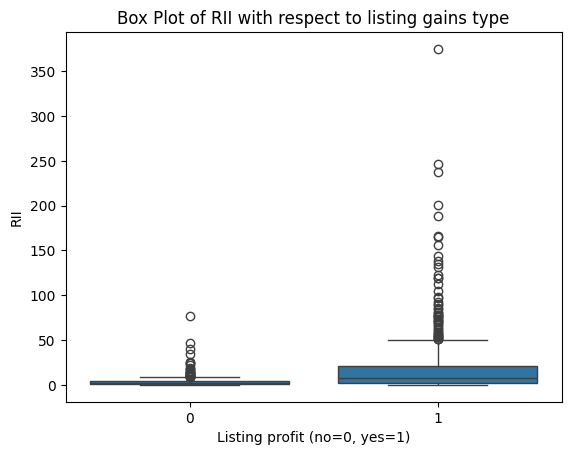

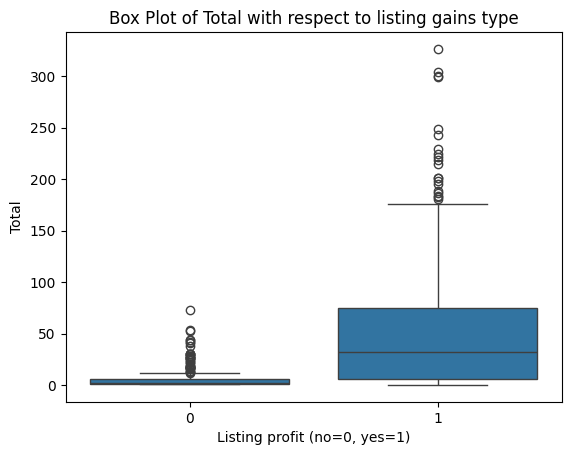

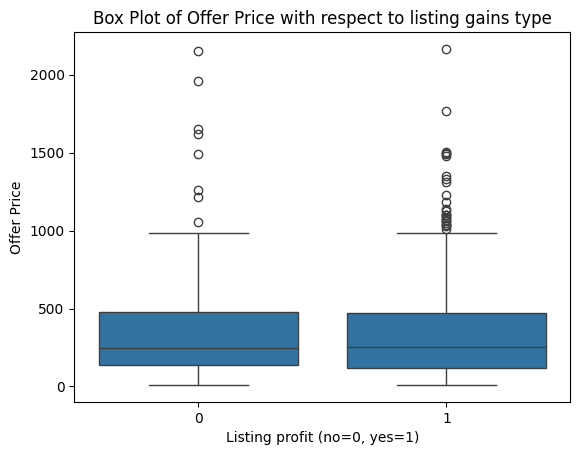

In [ ]:
for col in ['Issue_Size(crores)', 'QIB','HNI','RII','Total','Offer Price']:
  sns.boxplot(data=df_cleaned,x='Listing_gains_profit', y=col)
  plt.title(f'Box Plot of {col} with respect to listing gains type')
  plt.xlabel('Listing profit (no=0, yes=1)')
  plt.show()


In [ ]:
print(df_cleaned.skew())

Issue_Size(crores)      4.642241
QIB                     1.711949
HNI                     3.148485
RII                     4.898248
Total                   2.184687
Offer Price             1.928786
Listing_gains_profit   -0.792001
dtype: float64


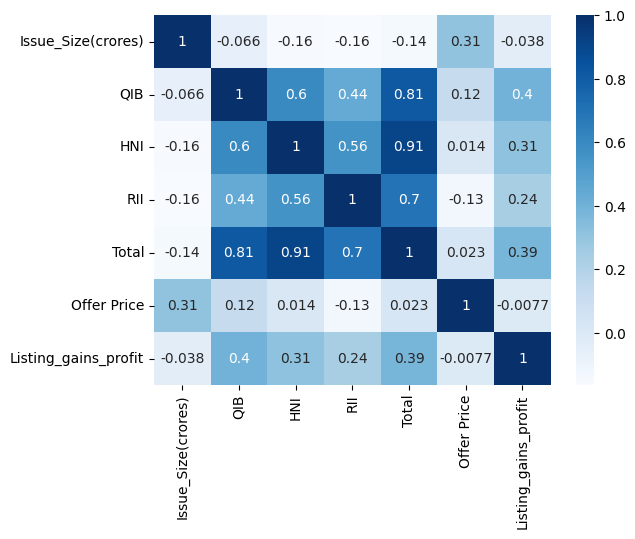

In [ ]:
correlation=df_cleaned.corr()
sns.heatmap(correlation, cmap='Blues', annot=True)
plt.show()

In [ ]:
# independent_vars=df_cleaned[['Issue_Size(crores)', 'QIB','HNI','RII','Total','Offer Price']]
# sns.pairplot(independent_vars, kind='scatter', plot_kws={'alpha':0.4})

In [ ]:
q1=df_cleaned['Issue_Size(crores)'].quantile(q=0.25)
q3=df_cleaned['Issue_Size(crores)'].quantile(q=0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
print('iqr=', iqr, '\nlower=',lower, '\nupper=', upper, sep='')

df_cleaned['Issue_Size(crores)']=df_cleaned['Issue_Size(crores)'].clip(lower,upper)
df_cleaned['Issue_Size(crores)'].describe()


iqr=985.9
lower=-1214.75
upper=2728.85


,Issue_Size(crores)
count,645.000000
mean,934.021116
std,878.984950
min,23.000000
25%,264.100000
50%,596.410000
75%,1250.000000
max,2728.850000


In [ ]:
q1=df_cleaned['QIB'].quantile(q=0.25)
q3=df_cleaned['QIB'].quantile(q=0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
print('iqr=', iqr, '\nlower=',lower, '\nupper=', upper, sep='')

df_cleaned['QIB']=df_cleaned['QIB'].clip(lower,upper)
df_cleaned['QIB'].describe()

iqr=74.27
lower=-108.785
upper=188.29500000000002


,QIB
count,645.000000
mean,46.382023
std,59.631566
min,0.000000
25%,2.620000
50%,13.470000
75%,76.890000
max,188.295000


In [ ]:
q1=df_cleaned['HNI'].quantile(q=0.25)
q3=df_cleaned['HNI'].quantile(q=0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
print('iqr=', iqr, '\nlower=',lower, '\nupper=', upper, sep='')

df_cleaned['HNI']=df_cleaned['HNI'].clip(lower,upper)
df_cleaned['HNI'].describe()

iqr=74.31
lower=-109.625
upper=187.615


,HNI
count,645.000000
mean,49.775605
std,66.026189
min,0.000000
25%,1.840000
50%,13.230000
75%,76.150000
max,187.615000


In [ ]:
q1=df_cleaned['RII'].quantile(q=0.25)
q3=df_cleaned['RII'].quantile(q=0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
print('iqr=', iqr, '\nlower=',lower, '\nupper=', upper, sep='')

df_cleaned['RII']=df_cleaned['RII'].clip(lower,upper)
df_cleaned['RII'].describe()

iqr=13.23
lower=-18.445
upper=34.475


,RII
count,645.000000
mean,10.059884
std,11.602269
min,0.000000
25%,1.400000
50%,4.780000
75%,14.630000
max,34.475000


In [ ]:
q1=df_cleaned['Total'].quantile(q=0.25)
q3=df_cleaned['Total'].quantile(q=0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
print('iqr=', iqr, '\nlower=',lower, '\nupper=', upper, sep='')

df_cleaned['Total']=df_cleaned['Total'].clip(lower,upper)
df_cleaned['Total'].describe()

iqr=54.42
lower=-79.36999999999999
upper=138.31


,Total
count,645.000000
mean,33.668109
std,42.167840
min,0.110000
25%,2.260000
50%,10.730000
75%,56.680000
max,138.310000


In [ ]:
q1=df_cleaned['Offer Price'].quantile(q=0.25)
q3=df_cleaned['Offer Price'].quantile(q=0.75)
iqr=q3-q1
lower=q1-1.5*iqr
upper=q3+1.5*iqr
print('iqr=', iqr, '\nlower=',lower, '\nupper=', upper, sep='')

df_cleaned['Offer Price']=df_cleaned['Offer Price'].clip(lower,upper)
df_cleaned['Offer Price'].describe()

iqr=355.0
lower=-412.5
upper=1007.5


,Offer Price
count,645.000000
mean,341.399225
std,274.525408
min,10.000000
25%,120.000000
50%,252.000000
75%,475.000000
max,1007.500000


In [ ]:
print(df_cleaned.skew())

Issue_Size(crores)      1.082785
QIB                     1.238406
HNI                     1.216743
RII                     1.205502
Total                   1.293200
Offer Price             1.050317
Listing_gains_profit   -0.792001
dtype: float64


In [ ]:
#deep learning model
from sklearn.preprocessing import MinMaxScaler
target = 'Listing_gains_profit'
predictors = df_cleaned.drop(columns=[target]).columns
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_cleaned[predictors])
X_scaled_df = pd.DataFrame(X_scaled, columns=predictors)
X_scaled_df.describe()

,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price
count,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000
mean,0.336686,0.246326,0.265307,0.291802,0.242823,0.332230
std,0.324846,0.316692,0.351924,0.336542,0.305122,0.275213
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.089103,0.013914,0.009807,0.040609,0.015557,0.110276
50%,0.211915,0.071537,0.070517,0.138651,0.076845,0.242607
75%,0.453462,0.408349,0.405884,0.424365,0.409334,0.466165
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
from sklearn.model_selection import train_test_split

target = 'Listing_gains_profit'

X = X_scaled_df.values
y = df_cleaned[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    #test_size=0.30,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 3. Print shapes to verify the sample counts
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape :", X_test.shape)
print("Training Labels Size   :", y_train.shape)
print("Testing Labels Size    :", y_test.shape)

Training Features Shape: (516, 6)
Testing Features Shape : (129, 6)
Training Labels Size   : (516,)
Testing Labels Size    : (129,)


In [ ]:
tf.random.set_seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(32, input_shape=(X_train.shape[1],), activation='relu'))
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dense(8, activation='relu'))
model.add(tf.keras.layers.Dense(4, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy', tf.keras.metrics.Recall()]
)
print(model.summary())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
model.fit(X_train, y_train, epochs=250)

Epoch 1/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4031 - loss: 0.7059 - recall_4: 0.4533
Epoch 2/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6783 - loss: 0.6857 - recall_4: 0.9915 
Epoch 3/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6841 - loss: 0.6759 - recall_4: 1.0000 
Epoch 4/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6841 - loss: 0.6591 - recall_4: 1.0000 
Epoch 5/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6841 - loss: 0.6388 - recall_4: 1.0000 
Epoch 6/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6841 - loss: 0.6156 - recall_4: 1.0000 
Epoch 7/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6841 - loss: 0.5910 - recall_4: 1.0000 
Epoch 8/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6841 - loss: 0.5666 - recall_4: 1.0000 
Epoch 9/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6841 - loss: 0.5439 - recall_4: 1.0000 
Epoch 10/250
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - ac

In [ ]:
model.evaluate(X_train, y_train)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7868 - loss: 0.4085 - recall_4: 0.8357  


[0.40847247838974, 0.786821722984314, 0.8356940746307373]

In [ ]:
model.evaluate(X_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7364 - loss: 0.5116 - recall_4: 0.7955 


[0.5115518569946289, 0.7364341020584106, 0.7954545617103577]